# Maxwell Turner - Assignment 3.5 - Housing Regressor - Week 3

## Setup
Seeds so I get the same results every run.

In [115]:
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Load & Prepare Data
Same cleanup as 3.2 fill missing bedrooms with the median one hot the ocean column

In [116]:
df = pd.read_csv("../data/california-housing.csv")
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df = pd.get_dummies(df, columns=["ocean_proximity"])
print("shape:", df.shape)

shape: (20640, 14)


Everything but `median_house_value` is an input dividing the target by 100k because raw dollars makes the MSE like 56 billion and SGD just explodes to NaN.

In [117]:
X = df.drop(columns=["median_house_value"]).to_numpy().astype("float32")
y = (df["median_house_value"] / 100000).to_numpy().astype("float32")

print("X shape:", X.shape)
print("y range:", y.min(), "to", y.max())

X shape: (20640, 13)
y range: 0.14999 to 5.00001


## Train/Test Split & Scaling
Fitting the scaler on train only, If I fit it on everything the test set leaks into the training stats

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
#fit on train only, then just transform test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("train:", X_train_s.shape, "test:", X_test_s.shape)
print("train mean:", round(float(X_train_s.mean()), 6))
print("test mean: ", round(float(X_test_s.mean()), 4))

train: (16512, 13) test: (4128, 13)
train mean: -0.0
test mean:  -0.0037


In [119]:
X_train_t = torch.from_numpy(X_train_s).float()
X_test_t = torch.from_numpy(X_test_s).float()
y_train_t = torch.from_numpy(y_train).float().view(-1, 1)
y_test_t = torch.from_numpy(y_test).float().view(-1, 1)
print(X_train_t.shape, y_train_t.shape)

torch.Size([16512, 13]) torch.Size([16512, 1])


## Define the Model
Regression MLP from 3.1 .The big difference from 2.5 is the output layer has NO activation. I want a raw dollar amount not a 0-1 probability.
I added a `mode` switch so I can compare plain vs BatchNorm vs Dropout later for the reflection questions

In [120]:
class RegressionMLP(nn.Module):
    def __init__(self, input_size, hidden_size=64, mode="plain", dropout_rate=0.2):
        super().__init__()
        self.mode = mode
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batchnorm = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.output = nn.Linear(hidden_size, 1)
    def forward(self, x):
        x = self.hidden(x)
        if self.mode == "batchnorm":
            x = self.batchnorm(x)#right after linear before relu
        x = self.relu(x)
        if self.mode == "dropout":
            x = self.dropout(x)#after the activation
        x = self.output(x)#no activation raw number
        return x

In [121]:
model = RegressionMLP(input_size=X_train_t.shape[1], hidden_size=64, mode="batchnorm")
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## Training Loop
Storing train and test loss every epoch so I can plot the curves. Switching between `model.train()` and `model.eval()` because BatchNorm and Dropout act differently in each mode.

In [122]:
n_epochs = 200
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    #Training
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    train_loss = loss_fn(outputs, y_train_t)
    train_losses.append(train_loss.item())
    train_loss.backward()
    optimizer.step()

    #Validation 
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = loss_fn(test_outputs, y_test_t)
        test_losses.append(test_loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"epoch {epoch+1:>4}  train {train_loss.item():.4f}  test {test_loss.item():.4f}")

epoch   40  train 0.4849  test 0.5037
epoch   80  train 0.4123  test 0.4267
epoch  120  train 0.3899  test 0.4031
epoch  160  train 0.3746  test 0.3859
epoch  200  train 0.3599  test 0.3718


## Results
MSE is in squared units so it's hard to read taking the square root gives RMSE which is back in the same units as the target so I can multiply by 100k and get a dollar amount

In [123]:
model.eval()
with torch.no_grad():
    train_mse = loss_fn(model(X_train_t), y_train_t).item()
    test_mse = loss_fn(model(X_test_t), y_test_t).item()
train_rmse = train_mse ** 0.5
test_rmse = test_mse ** 0.5
print(f"train MSE: {train_mse:.4f}   test MSE: {test_mse:.4f}")
print(f"train RMSE: {train_rmse:.4f}   test RMSE: {test_rmse:.4f}")
print(f"in dollars -> train ${train_rmse*100000:,.0f}   test ${test_rmse*100000:,.0f}")

train MSE: 0.3607   test MSE: 0.3718
train RMSE: 0.6006   test RMSE: 0.6098
in dollars -> train $60,058   test $60,979


## Plots
Train vs test loss to check the fit

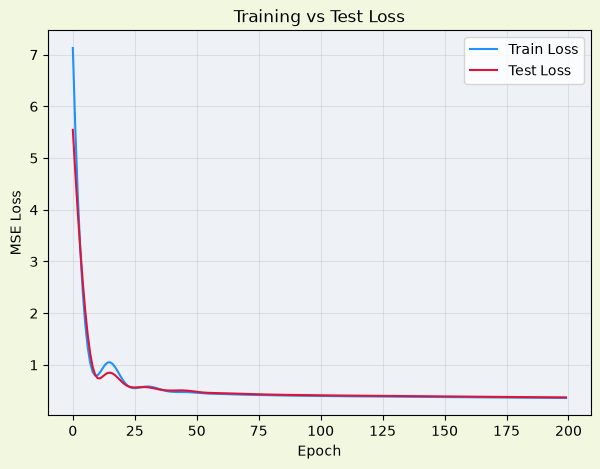

In [124]:
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.plot(train_losses, label="Train Loss", color="dodgerblue")
plt.plot(test_losses, label="Test Loss", color="crimson")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

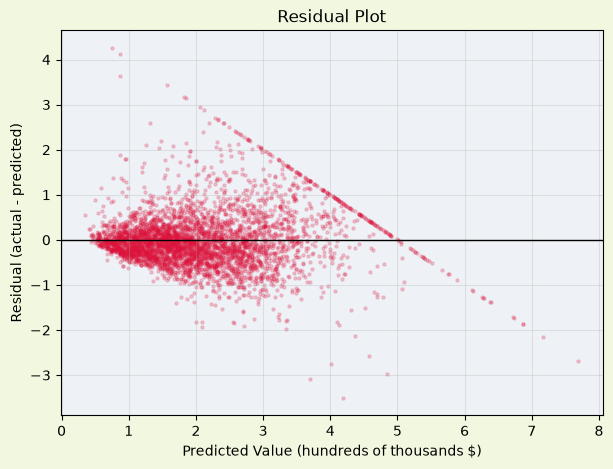

In [125]:
model.eval()
with torch.no_grad():
    preds = model(X_test_t)
residuals = (y_test_t - preds).numpy().ravel()
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.scatter(preds.numpy().ravel(), residuals, s=5, alpha=0.2, color="crimson")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted Value (hundreds of thousands $)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.show()

Residuals are mostly centered on 0 which is what I want. Two things stand out though the spread gets wider as predictions get bigger, so the model is less reliable on expensive districts and there's that sharp diagonal line which is the 500001 cap from 3.2. Those districts all have an actual value of exactly 5.0, so the residual is just 5.0 minus whatever was predicted which draws a straight line.

## Experiments
Comparing plain vs BatchNorm vs Dropout and checking whether standardizing the inputs actually mattered

In [126]:
def run(mode, epochs=200, lr=0.01, Xtr=None, Xte=None):
    if Xtr is None:
        Xtr, Xte = X_train_t, X_test_t
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    m = RegressionMLP(Xtr.shape[1], 64, mode=mode)
    fn = nn.MSELoss()
    op = torch.optim.Adam(m.parameters(), lr=lr)
    for _ in range(epochs):
        m.train()
        op.zero_grad()
        l = fn(m(Xtr), y_train_t)
        l.backward()
        op.step()
    m.eval()
    with torch.no_grad():
        tr = fn(m(Xtr), y_train_t).item()
        te = fn(m(Xte), y_test_t).item()
    return tr, te
for mode in ["plain", "batchnorm", "dropout"]:
    tr, te = run(mode)
    print(f"{mode:10} train MSE={tr:.4f}  test MSE={te:.4f}  "
          f"test RMSE=${te**0.5*100000:,.0f}")
#same thing but with raw unscaled inputs
Xtr_raw = torch.from_numpy(X_train).float()
Xte_raw = torch.from_numpy(X_test).float()
tr, te = run("plain", Xtr=Xtr_raw, Xte=Xte_raw)
print(f"{'unscaled':10} train MSE={tr:.4f}  test MSE={te:.4f}  "
      f"test RMSE=${te**0.5*100000:,.0f}")

plain      train MSE=0.3635  test MSE=0.3740  test RMSE=$61,155
batchnorm  train MSE=0.3607  test MSE=0.3718  test RMSE=$60,979
dropout    train MSE=0.3746  test MSE=0.3851  test RMSE=$62,056
unscaled   train MSE=7.7944  test MSE=15.4027  test RMSE=$392,463


## Reflection

**Did train/test curves stay close (good fit) or diverge (overfit/underfit)?**

They stayed close the whole time. Final train MSE was 0.3607 and test was 0.3718, which in dollars is about $60,058 vs $60,979 under a thousand dollars apart. On the plot the two lines basically sit on top of each other after the first 25 epochs. So no overfitting, the model learned the actual pattern instead of memorizing the training districts. It's not underfitting either since both losses dropped a lot from where they started around 7.If anything the model is limited by the data, not by training. Being off by $61k on a median value of $180k isn't amazing, but the residual plot shows why the errors get worse on expensive districts and there's that 500001 cap the model can't do anything about.

**Which helped more on this dataset: BatchNorm or Dropout?**

BatchNorm, but barely. BatchNorm got test MSE 0.3718 vs plain at 0.3740, so a tiny improvement. Dropout was actually worse at 0.3851.That makes sense because regularization is for fixing overfitting, and I didn't have any overfitting to fix. Dropout works by randomly turning off neurons so the model can't lean on one path, but my train and test scores were already almost identical, so there was nothing to correct  it just made training harder for no benefit. BatchNorm helped a little because it stabilizes the values flowing through the network, which speeds things up rather than reducing overfitting.

**Did standardized inputs help?**

Massively. Test MSE was 0.3740 with scaling and 15.4027 without, which is about 40x worse. In dollars that's $61,155 vs $392,463 the unscaled version is basically useless since it's off by more than most houses are worth. The reason is the columns are on completely different scales. `total_rooms` goes up past 39,000 while `median_income` maxes out at 15 and the one-hot columns are just 0 or 1. Without scaling, the huge columns dominate the weighted sums and the gradients, so the network can barely learn anything from the small ones. StandardScaler puts every column at mean 0 and std 1 so they all start out equally important.